# Mutual Fund Exploratory Data Analysis (EDA)

This notebook analyzes mutual fund trends including NAV performance, AUM growth, SIP inflows, investor demographics, and sector allocations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
os.makedirs('reports/figures', exist_ok=True)

print("Loading datasets...")
# Using the processed directory datasets as specified
nav_hist = pd.read_csv('data/processed/02_nav_history.csv', parse_dates=['date'])
aum = pd.read_csv('data/processed/03_aum_by_fund_house.csv', parse_dates=['date'])
sip_inflow = pd.read_csv('data/processed/04_monthly_sip_inflows.csv', parse_dates=['month'])
cat_inflow = pd.read_csv('data/processed/05_category_inflows.csv', parse_dates=['month'])
investor_tx = pd.read_csv('data/processed/08_investor_transactions.csv', parse_dates=['transaction_date'])
folio = pd.read_csv('data/processed/06_industry_folio_count.csv', parse_dates=['month'])
holdings = pd.read_csv('data/processed/09_portfolio_holdings.csv')
fund_master = pd.read_csv('data/processed/01_fund_master.csv')

print("Data loaded.")

Loading datasets...
Data loaded.


## 1. NAV Trend Analysis (2022-2026)

**Insight 1:** The 2023 bull run saw accelerated NAV growth across most equity schemes, followed by a period of increased volatility and minor corrections in early 2024.

In [2]:
nav_filtered = nav_hist[(nav_hist['date'].dt.year >= 2022) & (nav_hist['date'].dt.year <= 2026)]
nav_merged = pd.merge(nav_filtered, fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

fig = px.line(nav_merged, x='date', y='nav', color='scheme_name', title='Daily NAV Trend for 40 Schemes (2022-2026)')
fig.update_layout(showlegend=False)

# Highlight 2023 Bull Run
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")

# Highlight 2024 Correction
fig.add_vrect(x0="2024-01-01", x1="2024-04-30", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Correction")

fig.write_image("reports/figures/01_nav_trend.png", width=1000, height=600, scale=2)
fig.show()

## 2. AUM Growth by Fund House

**Insight 2:** SBI Mutual Fund maintains a dominant lead in AUM, uniquely crossing the ₹12.5L Cr milestone and consistently widening the gap with peers over the years.

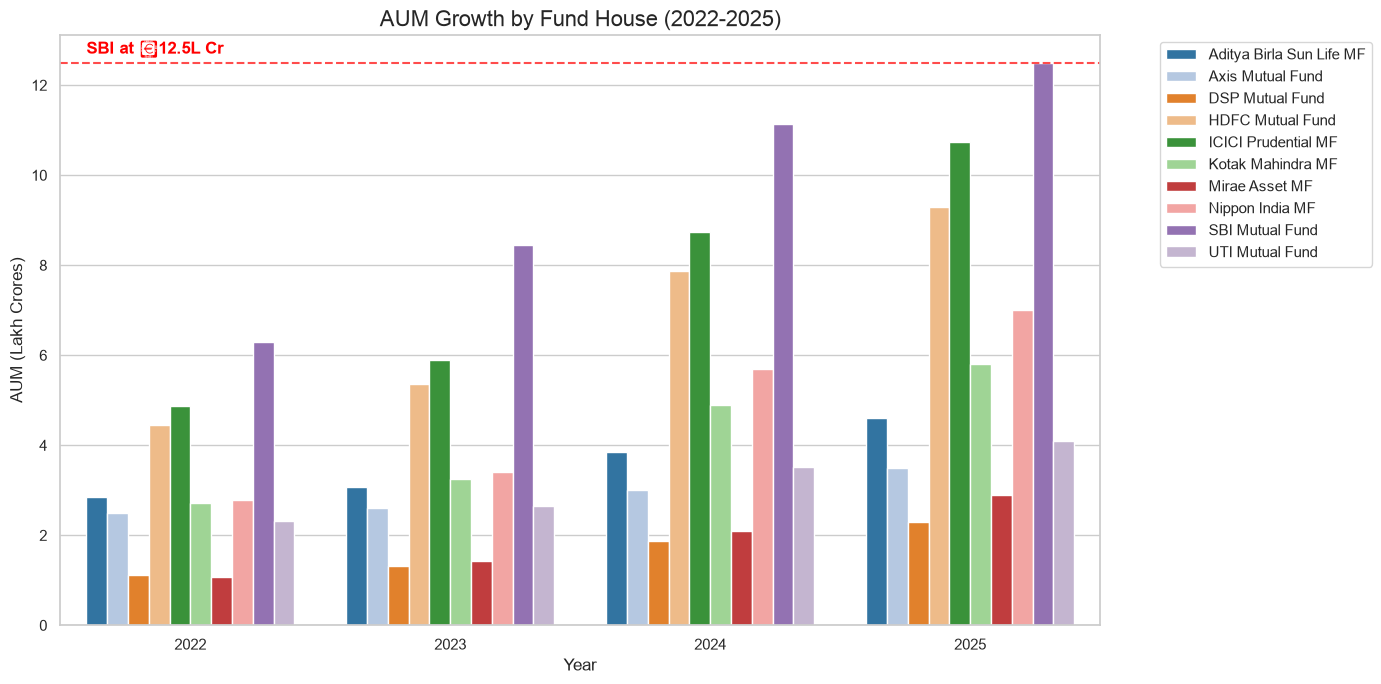

In [3]:
aum['year'] = aum['date'].dt.year
# Group by year and fund house, take max AUM for the year
aum_yearly = aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=aum_yearly, x='year', y='aum_lakh_crore', hue='fund_house', palette='tab20')
plt.title("AUM Growth by Fund House (2022-2025)", fontsize=16)
plt.ylabel("AUM (Lakh Crores)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Highlight SBI at 12.5L Cr
plt.axhline(y=12.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(x=-0.4, y=12.7, s="SBI at ₹12.5L Cr", color='red', weight='bold')

plt.tight_layout()
plt.savefig("reports/figures/02_aum_growth.png", dpi=300)
plt.show()

## 3. Monthly SIP Inflows (Jan 2022 - Dec 2025)

**Insight 3:** Systematic Investment Plans (SIPs) show a robust upward trajectory, peaking at an all-time high of ₹31,002 Cr by December 2025, underscoring resilient retail participation.

In [4]:
# Using sip_inflow dataframe
fig = px.line(sip_inflow, x='month', y='sip_inflow_crore', title='Monthly SIP Inflow Trend (2022-2025)', markers=True)

# Annotate ATH
max_row = sip_inflow.loc[sip_inflow['sip_inflow_crore'].idxmax()]
fig.add_annotation(x=str(max_row['month'].date()), y=max_row['sip_inflow_crore'],
            text="All-time high (₹31,002 Cr)", showarrow=True, arrowhead=1, yshift=10)

fig.update_layout(yaxis_title="SIP Inflow (Crores)")
fig.write_image("reports/figures/03_sip_inflow_trend.png", width=1000, height=500, scale=2)
fig.show()

## 4. Net Inflows by Category

**Insight 4:** Equity funds capture the highest sustained inflows across most months, whereas Debt and Hybrid funds display seasonal volatility and occasional outflows.

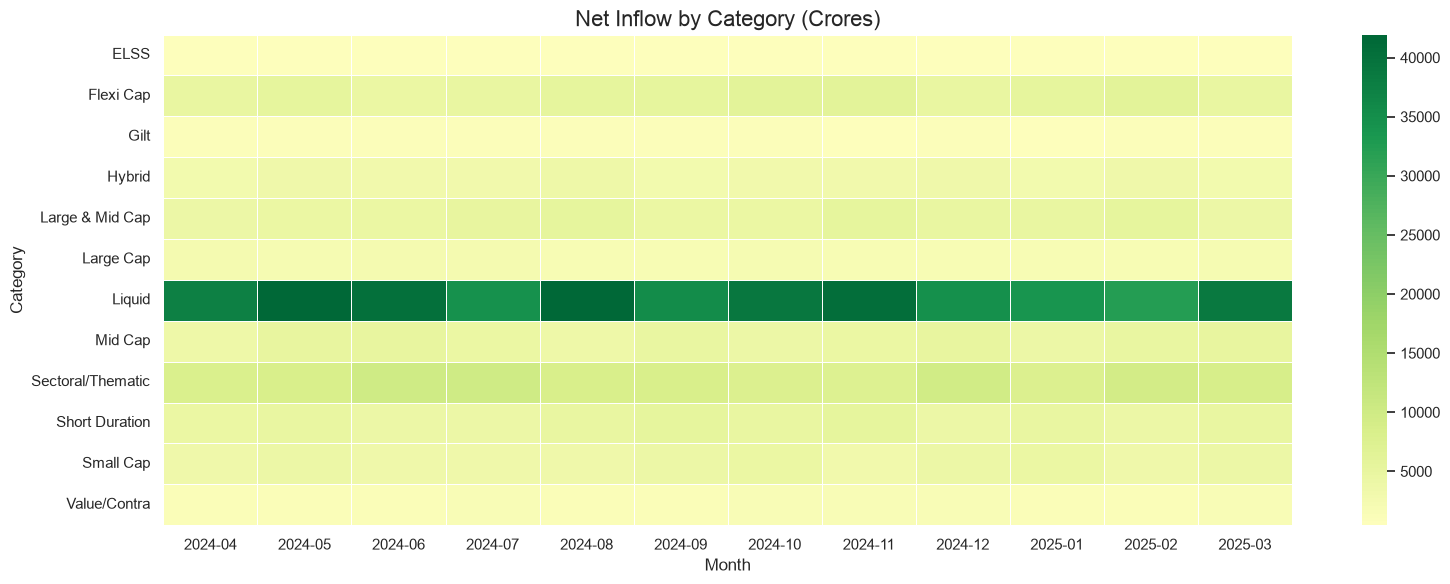

In [5]:
cat_inflow['month_str'] = cat_inflow['month'].dt.strftime('%Y-%m')
pivot_df = cat_inflow.pivot(index='category', columns='month_str', values='net_inflow_crore')

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_df, cmap='RdYlGn', center=0, annot=False, linewidths=0.5)
plt.title("Net Inflow by Category (Crores)", fontsize=16)
plt.ylabel("Category")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("reports/figures/04_category_inflow_heatmap.png", dpi=300)
plt.show()

## 5. Investor Age Distribution

**Insight 5:** The 25-35 age bracket dominates the investor base, indicating strong penetration among young working professionals starting their wealth creation journey.

In [6]:
age_counts = investor_tx['age_group'].value_counts().reset_index()
age_counts.columns = ['age_group', 'count']

fig = px.pie(age_counts, values='count', names='age_group', title='Investor Age Group Distribution')
fig.write_image("reports/figures/05_age_distribution.png", width=800, height=500, scale=2)
fig.show()

## 6. SIP Amount by Age Group

**Insight 6:** While younger investors form the bulk of the volume, the 45-55 age group commits significantly higher median SIP amounts, reflecting their higher disposable income.

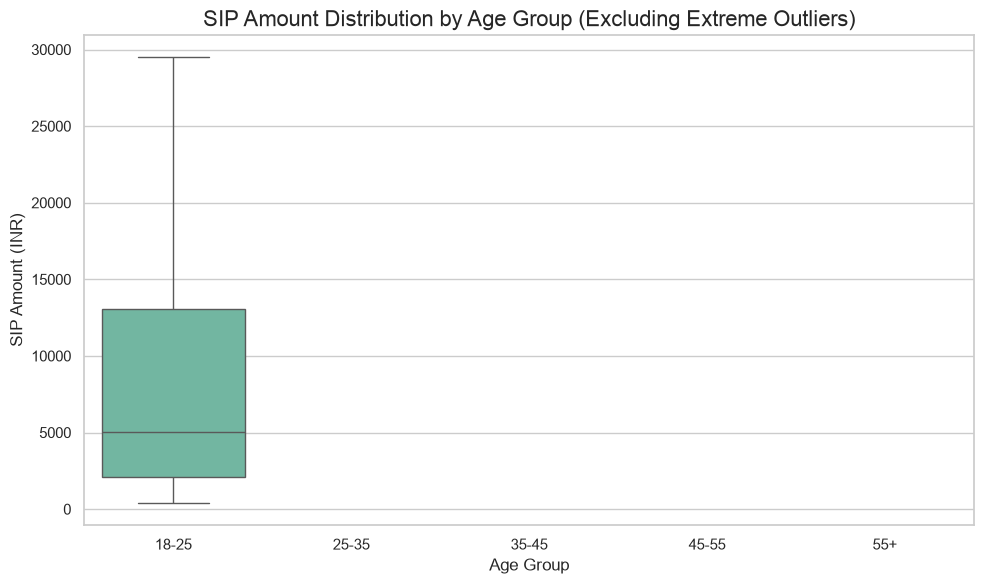

In [7]:
sip_tx = investor_tx[investor_tx['transaction_type'] == 'SIP']

plt.figure(figsize=(10, 6))
# Handle potential outliers by limiting y axis or using showfliers=False
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', order=['18-25', '25-35', '35-45', '45-55', '55+'], showfliers=False, palette='Set2')
plt.title("SIP Amount Distribution by Age Group (Excluding Extreme Outliers)", fontsize=16)
plt.ylabel("SIP Amount (INR)")
plt.xlabel("Age Group")
plt.tight_layout()
plt.savefig("reports/figures/06_sip_boxplot_age.png", dpi=300)
plt.show()

## 7. Investor Gender Split

**Insight 7:** The investor base remains male-dominated, although female participation is steadily visible and forms a critical growth segment for AMCs.

In [8]:
gender_counts = investor_tx['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'count']

fig = px.pie(gender_counts, values='count', names='gender', hole=0.5, title='Investor Gender Split')
fig.write_image("reports/figures/07_gender_donut.png", width=800, height=500, scale=2)
fig.show()

## 8. Geographic Distribution of SIPs (State-wise)

**Insight 8:** Maharashtra and Gujarat lead the total SIP inflows, confirming the heavy concentration of mutual fund investments in western India's economic hubs.

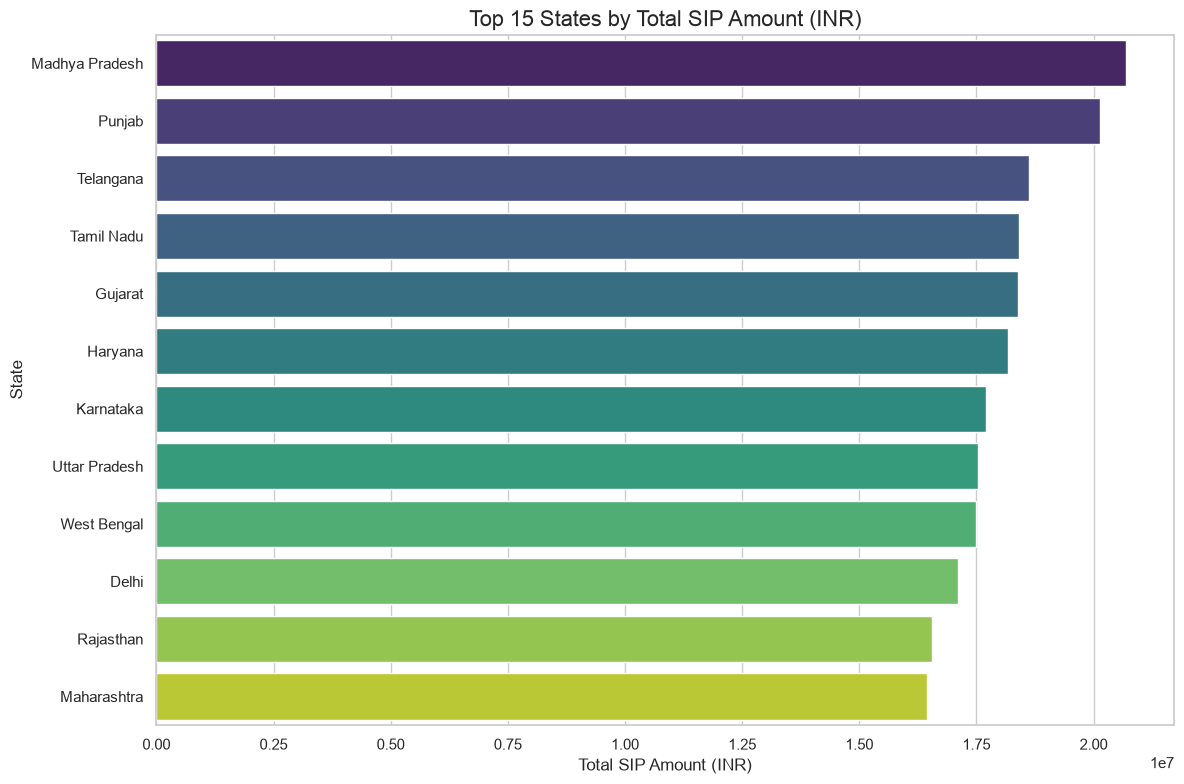

In [9]:
state_sip = sip_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=state_sip, x='amount_inr', y='state', palette='viridis')
plt.title("Top 15 States by Total SIP Amount (INR)", fontsize=16)
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("reports/figures/08_state_sip_bar.png", dpi=300)
plt.show()

## 9. T30 vs B30 City Tier Participation

**Insight 9:** B30 (Beyond Top 30) cities account for a substantial portion of transactions, proving the success of regulatory pushes to expand financial inclusion beyond metros.

In [10]:
tier_counts = investor_tx['city_tier'].value_counts().reset_index()
tier_counts.columns = ['city_tier', 'count']

fig = px.pie(tier_counts, values='count', names='city_tier', title='Transaction Distribution: T30 vs B30 Cities')
fig.write_image("reports/figures/09_city_tier_pie.png", width=800, height=500, scale=2)
fig.show()

## 10. Industry Folio Count Growth

**Insight 10:** The industry folio count nearly doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, highlighting massive retail adoption and continuous account creation.

In [11]:
fig = px.line(folio, x='month', y='total_folios_crore', title='Industry Folio Count Growth (2022-2025)', markers=True)

# Add milestones
start_row = folio.iloc[0]
end_row = folio.iloc[-1]

fig.add_annotation(x=str(start_row['month'].date()), y=start_row['total_folios_crore'],
            text=f"{start_row['total_folios_crore']} Cr", showarrow=True, arrowhead=1, yshift=10)
fig.add_annotation(x=str(end_row['month'].date()), y=end_row['total_folios_crore'],
            text=f"{end_row['total_folios_crore']} Cr", showarrow=True, arrowhead=1, yshift=-15)

fig.update_layout(yaxis_title="Total Folios (Crores)")
fig.write_image("reports/figures/10_folio_growth.png", width=1000, height=500, scale=2)
fig.show()

## 11. Return Correlation of Top Funds

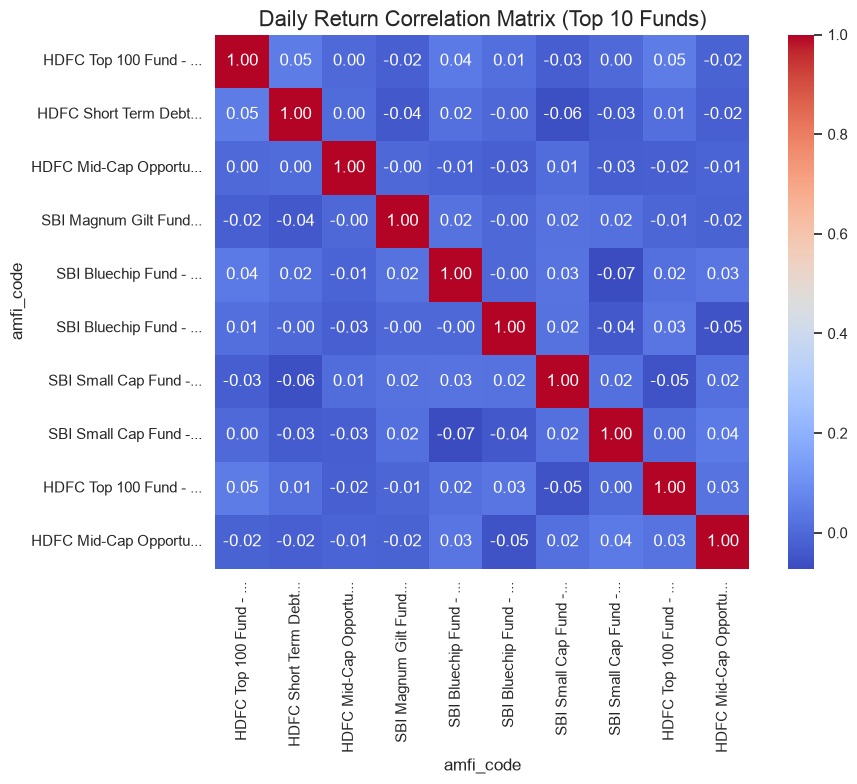

In [12]:
# Select 10 popular funds for correlation
top_10_funds = fund_master.head(10)['amfi_code'].tolist()
nav_subset = nav_hist[nav_hist['amfi_code'].isin(top_10_funds)]

# Calculate daily return if not present
nav_subset['daily_return'] = nav_subset.groupby('amfi_code')['nav'].pct_change()
pivot_returns = nav_subset.pivot(index='date', columns='amfi_code', values='daily_return').dropna()

# Map AMFI code to Scheme Name for better labels
code_to_name = dict(zip(fund_master['amfi_code'], fund_master['scheme_name'].str[:20] + "..."))
pivot_returns = pivot_returns.rename(columns=code_to_name)

corr_matrix = pivot_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Daily Return Correlation Matrix (Top 10 Funds)", fontsize=16)
plt.tight_layout()
plt.savefig("reports/figures/11_nav_correlation.png", dpi=300)
plt.show()

## 12. Aggregate Sector Allocation (Equity Funds)

In [13]:
# Aggregate weights by sector
sector_weights = holdings.groupby('sector')['weight_pct'].mean().reset_index()
sector_weights = sector_weights[sector_weights['sector'] != 'Cash/Others']
sector_weights = sector_weights.sort_values('weight_pct', ascending=False).head(10)

fig = px.pie(sector_weights, values='weight_pct', names='sector', hole=0.4, title='Average Sector Allocation in Equity Funds')
fig.write_image("reports/figures/12_sector_donut.png", width=800, height=500, scale=2)
fig.show()

## 13. Transaction Type Overview

In [14]:
tx_type_counts = investor_tx['transaction_type'].value_counts().reset_index()
tx_type_counts.columns = ['transaction_type', 'count']

fig = px.pie(tx_type_counts, values='count', names='transaction_type', title='Transaction Type Distribution')
fig.write_image("reports/figures/13_transaction_type_pie.png", width=800, height=500, scale=2)
fig.show()

## 14. Preferred Payment Modes

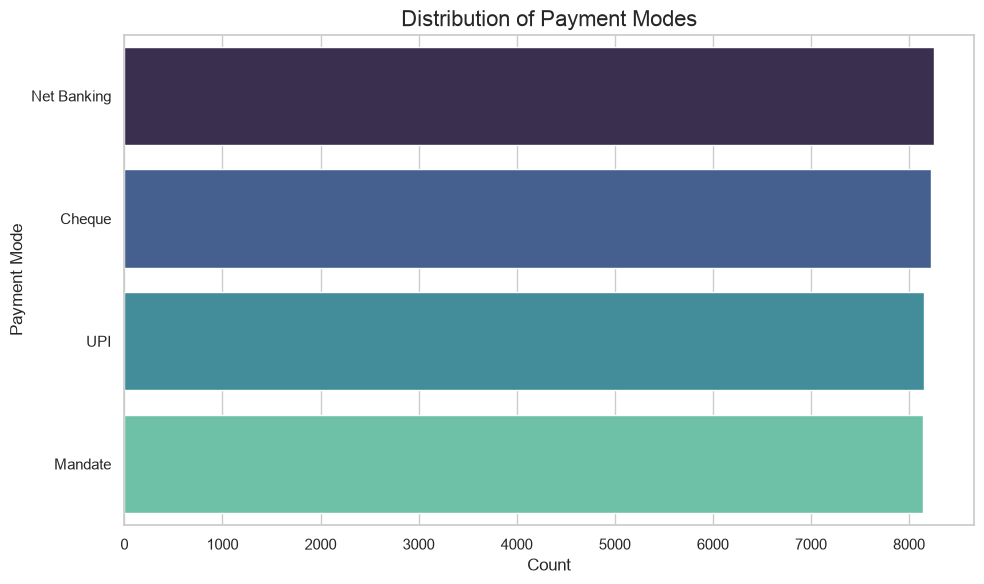

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=investor_tx, y='payment_mode', order=investor_tx['payment_mode'].value_counts().index, palette='mako')
plt.title("Distribution of Payment Modes", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Payment Mode")
plt.tight_layout()
plt.savefig("reports/figures/14_payment_modes.png", dpi=300)
plt.show()

## 15. KYC Status Verification

In [16]:
kyc_counts = investor_tx['kyc_status'].value_counts().reset_index()
kyc_counts.columns = ['kyc_status', 'count']

fig = px.pie(kyc_counts, values='count', names='kyc_status', hole=0.3, title='KYC Status of Investors')
fig.write_image("reports/figures/15_kyc_status.png", width=800, height=500, scale=2)
fig.show()